# Compare methods

WYM を参考に以下2点とcossimを組み合わせて評価する

- Faithful
  - 評価方法(WYMと同じ)
    - TokenPairのみのEntityPairでのマッチャー結果と、元のマッチャー結果とが同じとなる確率
  - 計測対象のレコードペア
    - マッチャーがMatchの結果をだしたレコードのみ or 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k -> match_score(k token pair のみ追加した時の match score)
- Contribution
  - 評価方法(WYMと同じ)
    - TokenPairを削除したEntityPairのマッチャー結果でのF1スコアのMoRF
  - 計測対象のレコードペア
    - マッチャーがMatchの結果を出したレコードのみ OR 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k -> match_score(k token pair のみ削除した時の match score)
- TokenPairのわかりやすさ
  - 評価方法（今までと同じ）
    - コサイン類似度
  - 計測対象のレコードペア
    - マッチャーがMatchの結果を出したレコードのみ OR 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k -> cos_sim(k token pair 番目のcos sim)
- ペアで動作しているか
  - 評価方法
    - ペア削除したときと、片方削除した時のMatchScoreが同じ。
    - ペア削除したときと、片方削除したときの判定結果が同じ
  - 計測対象のレコードペア
    - マッチャーがMatchの結果を出したレコードのみ OR 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k 
      - k ペア削除した時のMatchScore
      - kペアの右側を削除した時のMatchScore
      - kペアの左側を削除した時のMatchScore

これらの組合せで総合指標を作る


In [1]:
# matcher_names = ["bert_mini", "magellan"]
matcher_names = ["wym"]
dataset_root_dir = "../../data/lemon/datasets"
eval_data_root_dir = "../../data/experiments/11_eval"
lime_result_root_dir = "../../data/experiments/11_eval/lime_result_wym_matcher"
wym_result_root_dir = "../../data/experiments/11_eval/wym_result"
token_sim_result_root_dir = "../../data/experiments/10_eval/sim_token_score"
token_sim_wup_result_root_dir = "../../data/experiments/11_eval/sim_token_score_wup"
dataset_names = [
    "structured_amazon_google",
    "structured_beer",
    "structured_dblp_acm",
    "structured_dblp_google_scholar",
    "structured_fodors_zagat",
    "structured_walmart_amazon",
    "structured_itunes_amazon",
    "dirty_dblp_acm",
    "dirty_dblp_google_scholar",
    "dirty_walmart_amazon",
    "dirty_itunes_amazon",
    "textual_abt_buy",
    "textual_company",
]
methods = [
    "wym_pine",  # WYM_PINE
    "wym",  # WYM_WYM
]

target_dataset_idxs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
target_matcher_idxs = [0]
target_method_idxs = [0, 1]

In [2]:
TOP_N = 5

In [3]:
# グラフ内に表示する名前に変換する対応表
## 用いないもの以外は、コメントアウトしておく（これにより、表示時に間違えないようにする）
matcher_names_maps = {
    "wym": "WYM",
}
datasetname_maps = {
    "structured_amazon_google": "S_AG",
    "structured_beer": "S_BE",
    "structured_dblp_acm": "S_DA",
    "structured_dblp_google_scholar": "S_DG",
    "structured_fodors_zagat": "S_FZ",
    "structured_walmart_amazon": "S_WA",
    "structured_itunes_amazon": "S_IA",
    "dirty_dblp_acm": "D_DA",
    "dirty_dblp_google_scholar": "D_DG",
    "dirty_walmart_amazon": "D_WA",
    "dirty_itunes_amazon": "D_IA",
    "textual_abt_buy": "T_AB",
}
methods_map = {
    "wym_attribution_and_simtoken_mod3": "PINE",
    "wym": "WYM",
}
# メソッドに使うマーカーの種類（白黒でも対応できるように）
## マーカーの数は、target_method_idxs と同じ数
# markers = ["o", "v", "s", "x", "+", "x"]
markers = ["s", "d", "x", "+", "v", "o", "o"]
color_palette = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]
line_styles = ["-", "--", "-.", ":", "-.", "-"]


## データセットを読み込む

In [4]:
from pine.dataset import load_dataset
from functools import lru_cache


@lru_cache(maxsize=None)
def test_load_dataset():
    dataset_name = dataset_names[target_dataset_idxs[0]]
    dataset = load_dataset(dataset_name, dataset_root_dir)
    display(dataset.test.records.a.head())
    display(dataset.test.records.b.head())
    display(dataset.test.record_id_pairs.head())
    display(dataset.test.labels.head())
    print(dataset.test.records.a.dtypes)
    print("Test DATA SIZE =", len(dataset.test.record_id_pairs))


test_load_dataset()

,title,manufacturer,price
__id,,,
0,clickart 950 000 premier image pack ( dvd-rom ),broderbund,<NA>
1,ca international arcserve lap/desktop oem 30pk,computer associates,<NA>
2,noah 's ark activity center ( jewel case ages ...,victory multimedia,<NA>
3,peachtree by sage premium accounting for nonpr...,sage software,599.99
4,singing coach unlimited,carry-a-tune technologies,99.99


,title,manufacturer,price
__id,,,
0,learning quickbooks 2007,intuit,38.99
1,superstart ! fun with reading & writing !,<NA>,8.49
2,qb pos 6.0 basic software,intuit,637.99
3,math missions : the amazing arcade adventure (...,<NA>,12.95
4,production prem cs3 mac upgrad,adobe software,805.99


,a.rid,b.rid
pid,,
0,393,831
1,559,324
2,558,3023
3,762,1618
4,1262,2860


pid
0    False
1    False
2    False
3    False
4    False
Name: label, dtype: bool

title            string
manufacturer     string
price           Float64
dtype: object
Test DATA SIZE = 2293


## Lime 結果を読み込む

オリジナルのmatch_scoreを取得するため

In [5]:
from typing import Dict, List, Tuple
import pathlib
import pickle
from dataclasses import dataclass
from pine.explainer import AttributionScore


@dataclass
class LimeResult:
    attributions_l: List[AttributionScore]
    attributions_r: List[AttributionScore]
    match_score: float
    lime_intercept: float
    lime_pred_score: float
    lime_match_score: float


@lru_cache(maxsize=None)
def load_lime_result(
    target_dataset_name: str,
    target_matcher_name: str,
    dir_path: pathlib.Path,
) -> Dict[int, Dict[Tuple[int, int], LimeResult]]:
    dir_path = dir_path / target_matcher_name / target_dataset_name
    id_to_pairdel_to_results = {}
    for file_path in dir_path.glob("*.pickle"):
        with file_path.open("rb") as f:
            data = pickle.load(f)

        # lime結果を分かりやすいオブジェクトでラップする
        data_coverted = {}
        for id, result in data.items():
            data_coverted[id] = {}
            for k, v in result.items():
                data_coverted[id][k] = LimeResult(*v)

        id_to_pairdel_to_results.update(data_coverted)
    return id_to_pairdel_to_results


def test_load_lime_result():
    target_dataset_name = dataset_names[target_dataset_idxs[0]]
    target_matcher_name = matcher_names[target_matcher_idxs[0]]
    ret = load_lime_result(
        target_dataset_name, target_matcher_name, pathlib.Path(lime_result_root_dir)
    )
    for i, (idx, pair_scores) in enumerate(ret.items()):
        print(idx)
        print(pair_scores)
        if i >= 10:
            break


test_load_lime_result()

0
{(None, None): LimeResult(attributions_l=[AttributionScore(index=1, score=-0.06063689139285042), AttributionScore(index=7, score=-0.059223442571836676), AttributionScore(index=4, score=-0.057750371930262105), AttributionScore(index=3, score=-0.05651106267380903), AttributionScore(index=5, score=-0.054397196272042), AttributionScore(index=8, score=-0.05344107484885047), AttributionScore(index=11, score=-0.050974848715575206), AttributionScore(index=2, score=-0.04978272463961835), AttributionScore(index=10, score=-0.049435600043814865), AttributionScore(index=0, score=-0.044391140597889456), AttributionScore(index=9, score=-0.04288635824745805), AttributionScore(index=6, score=-0.04188117500118018)], attributions_r=[AttributionScore(index=7, score=-0.065274970523113), AttributionScore(index=2, score=-0.061178205704598254), AttributionScore(index=3, score=-0.059348771709430564), AttributionScore(index=4, score=-0.05874246049369177), AttributionScore(index=6, score=-0.054212920798313316)

## 各手法のpair explanationデータを取得

In [6]:
from pine.entity import EntityPair


@dataclass
class LimeResultPair:
    attributions: List[AttributionScore]
    match_score: float
    lime_intercept: float
    lime_pred_score: float
    lime_match_score: float


@lru_cache(maxsize=None)
def load_pair_explanations(
    target_method_name: str,
    target_dataset_name: str,
    target_matcher_name: str,
    pair_explanation_root_dir_path: pathlib.Path = None,
) -> Dict[int, Tuple[LimeResultPair, EntityPair]]:
    pair_explanations_file_path = (
        pair_explanation_root_dir_path
        / target_method_name
        / target_matcher_name
        / target_dataset_name
        / "pair_explanations.pickle"
    )

    with pair_explanations_file_path.open("rb") as f_in:
        pair_explanations = pickle.load(f_in)
    # もともと、PairExplanationはattrinution score の絶対値の大きい順で並んでいる。今回はそのまま使う。
    return pair_explanations


def test_load_pair_explanations():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    target_matcher_name = matcher_names[0]
    target_method_name = methods[0]
    pair_explanations = load_pair_explanations(
        target_method_name,
        target_dataset_name,
        target_matcher_name,
        pathlib.Path(eval_data_root_dir),
    )
    for i, (idx, exp) in enumerate(pair_explanations.items()):
        print(idx)
        print(exp)
        if i >= 10:
            break


test_load_pair_explanations()

0
(LimeResultPair(attributions=[AttributionScore(index=3, score=-0.7960972326170911), AttributionScore(index=4, score=-0.42562472092160686), AttributionScore(index=2, score=-0.32913130501691157), AttributionScore(index=0, score=-0.11782774690986592), AttributionScore(index=1, score=-0.07288788352031184)], match_score=-0.9555125812667794, lime_intercept=0.6101870086179967, lime_pred_score=0.6556912374072372, lime_match_score=-1.1313818803677904), <pine.entity.EntityPair object at 0x7efe6b782f50>)
1
(LimeResultPair(attributions=[AttributionScore(index=2, score=-0.1320692210508643), AttributionScore(index=3, score=-0.09295932675506048), AttributionScore(index=4, score=-0.05508344069505367), AttributionScore(index=1, score=-0.05023199996935854), AttributionScore(index=0, score=-0.016471488584010905)], match_score=-0.9985879340375449, lime_intercept=-0.6928182124385869, lime_pred_score=0.6701361250942717, lime_match_score=-1.0396336894929348), <pine.entity.EntityPair object at 0x7efe6b78b05

### WYM 結果を読み込む、LimePair結果にコンバートする

In [7]:
from typing import Dict, List, Tuple
import pathlib
import pickle
from dataclasses import dataclass
from pine.explainer import AttributionScore
from pine.entity import Entity, EntityPair
from pine.entity import MergedSegment


@dataclass
class WymResult:
    attributions: List[AttributionScore]
    match_score: float
    wym_intercept: float
    wym_pred_score: float
    wym_match_score: float
    dummy: float
    tokens_pairs: List[Tuple[str, str]]
    entity_pair: EntityPair


@dataclass
class LimeResultPair:
    attributions: List[AttributionScore]
    match_score: float
    lime_intercept: float
    lime_pred_score: float
    lime_match_score: float


def get_token_to_segment_id(entity: Entity):
    """エンティティ内のtokenに対応するセグメントのIDの辞書を返す"""
    token_to_segidx = {}
    for idx in range(entity.segment_size()):
        token = entity.get_segment_label(idx)
        token_to_segidx[token] = idx
    return token_to_segidx


def check_token_in_segments(token_to_segidx: Dict[str, int], tokens: List[str]):
    for token in tokens:
        if token not in token_to_segidx:
            print(
                f'WARNING: token "{token}" is not found in segments. {list(token_to_segidx.keys())}'
            )
    return


def convert_wym_to_limepair(
    wym_result: WymResult, topk: int
) -> Tuple[LimeResultPair, EntityPair]:
    """Wym結果をLimeペア結果とEntityPairに変換する。
    EntityPairはExptanationに使われたtokenpairがマージされている状態のものを作る。
    attributionsもこれに合わせてインデックスを作成する。
    ただし、スコアの大きい順にtopk個のみを返す。"""

    # token_pairとentity_pairのインデックスの対応をとる
    entity_pair = wym_result.entity_pair
    token_l_to_idx_in_entity = get_token_to_segment_id(entity_pair.entity_l)
    token_r_to_idx_in_entity = get_token_to_segment_id(entity_pair.entity_r)
    # トークンが存在することを確かめる（ただし、ペア相手がいないことを示す"[UNP]"以外）
    check_token_in_segments(
        token_l_to_idx_in_entity,
        [t[0] for t in wym_result.tokens_pairs if t[0] != "[UNP]"],
    )
    check_token_in_segments(
        token_r_to_idx_in_entity,
        [t[1] for t in wym_result.tokens_pairs if t[1] != "[UNP]"],
    )

    # topk個のみのtoken_pairsを取り出す
    attributions_topk = sorted(
        wym_result.attributions, key=lambda attr: abs(attr.score), reverse=True
    )[:topk]
    token_pairs_topk = []
    for attr in attributions_topk:
        token_pairs_topk.append(wym_result.tokens_pairs[attr.index])

    # mergeしたentity_pairを作成
    merging_segment_list: List[MergedSegment] = []
    token_idx_pairs_topk = []
    for token_l, token_r in token_pairs_topk:
        idx_l = token_l_to_idx_in_entity.get(token_l)
        idx_r = token_r_to_idx_in_entity.get(token_r)
        token_idx_pairs_topk.append((idx_l, idx_r))
        # 見つからない原因が"[UNP]"ではない場合はスキップ
        if idx_l is None and token_l != "[UNP]":
            print(
                f"WARNING: token pair {token_l, token_r} = {idx_l, idx_r} is not found in entity pair."
            )
            token_idx_pairs_topk.append(())
            continue
        if idx_r is None and token_r != "[UNP]":
            print(
                f"WARNING: token pair {token_l, token_r} = {idx_l, idx_r} is not found in entity pair."
            )
            token_idx_pairs_topk.append(())
            continue
        if idx_l is None and idx_r is None:
            print(
                f"WARNING: token pair {token_l, token_r} = {idx_l, idx_r} is not found in entity pair."
            )
            token_idx_pairs_topk.append(())
            continue
        merge_seg = MergedSegment([], [])
        if idx_l is not None:
            merge_seg.segment_list_in_l.append(idx_l)
        if idx_r is not None:
            merge_seg.segment_list_in_r.append(idx_r)
        merging_segment_list.append(merge_seg)
    entity_pair_merged = entity_pair.make_entity_pair_by_merging_segment_list_only(
        merging_segment_list
    )

    # attributionsのインデックスを更新
    attributions_new = []
    for attr, (idx_l, idx_r) in zip(attributions_topk, token_idx_pairs_topk):
        idx_ls = [idx_l] if idx_l is not None else []
        idx_rs = [idx_r] if idx_r is not None else []
        idx_in_entity_pair = None
        for idx in range(entity_pair_merged.segment_size()):
            idx_ls_in_ep, idx_rs_in_ep = (
                entity_pair_merged.convert_segment_idx_to_entity_idx(idx)
            )
            if idx_ls_in_ep == idx_ls and idx_rs_in_ep == idx_rs:
                idx_in_entity_pair = idx
                break
        if idx_in_entity_pair is None:
            print(
                f"WARNING: token idx pair {idx_l, idx_r} is not found in entity pair."
            )
            continue
        attributions_new.append(AttributionScore(idx_in_entity_pair, attr.score))

    lime_pair_result = LimeResultPair(
        attributions_new,
        wym_result.match_score * 2 - 1.0,
        wym_result.wym_intercept,
        wym_result.wym_pred_score,
        wym_result.wym_match_score,
    )
    return lime_pair_result, entity_pair_merged


def load_wym_pair_explanation(
    target_dataset_name: str,
    pair_explanation_root_dir_path: pathlib.Path = None,
) -> Dict[int, Tuple[LimeResultPair, EntityPair]]:
    pair_explanations_dir_path = pair_explanation_root_dir_path / target_dataset_name
    results = {}
    for file_path in pair_explanations_dir_path.glob("*.pickle"):
        with file_path.open("rb") as f:
            data = pickle.load(f)
        # Wym結果を分かりやすいオブジェクトでラップする
        data_coverted = {}
        for id, result in data.items():
            data_coverted[id] = convert_wym_to_limepair(WymResult(*result), TOP_N)
        results.update(data_coverted)

    return results


def test_convert_wym_to_limepair():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    pair_explanations_dir_path = pathlib.Path(wym_result_root_dir) / target_dataset_name
    wym_results = []
    for file_path in pair_explanations_dir_path.glob("*.pickle"):
        with file_path.open("rb") as f:
            data = pickle.load(f)
        for result in data.values():
            wym_results.append(WymResult(*result))
            if len(wym_results) >= 100:
                break
    for wym_result in wym_results:
        lime_result_pair, entity_pair = convert_wym_to_limepair(wym_result, TOP_N)
        # matcher_score は -1.0 から 1.0 になる
        assert wym_result.match_score * 2 - 1.0 == lime_result_pair.match_score
        # attributionsのインデックスに対応するtokenとスコアが同じであることを確認
        token_pair_scores_in_ep = []
        for attr in lime_result_pair.attributions:
            score = attr.score
            idx = attr.index
            idx_ls, idx_rs = entity_pair.convert_segment_idx_to_entity_idx(idx)
            tolen_l = (
                entity_pair.entity_l.get_segment_label(idx_ls[0])
                if len(idx_ls) > 0
                else "[UNP]"
            )
            tolen_r = (
                entity_pair.entity_r.get_segment_label(idx_rs[0])
                if len(idx_rs) > 0
                else "[UNP]"
            )
            token_pair_scores_in_ep.append(((tolen_l, tolen_r), score))
        token_pair_scores_in_wym = []
        for attr in sorted(
            wym_result.attributions, key=lambda attr: abs(attr.score), reverse=True
        ):
            token_pair_scores_in_wym.append(
                (wym_result.tokens_pairs[attr.index], attr.score)
            )
        for token_pair_score_in_ep, token_pair_score_in_wym in zip(
            token_pair_scores_in_ep, token_pair_scores_in_wym
        ):
            assert token_pair_score_in_ep == token_pair_score_in_wym


def test_load_wym_pair_explanation():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    ret = load_wym_pair_explanation(
        target_dataset_name,
        pathlib.Path(wym_result_root_dir),
    )
    for i, (pid, exp) in enumerate(ret.items()):
        print(pid)
        print(exp[0])
        print(exp[1].merged_segment_list)
        display(exp[1].entity_l.to_dataframe())
        display(exp[1].entity_r.to_dataframe())
        if i >= 10:
            break


test_convert_wym_to_limepair()
test_load_wym_pair_explanation()

0
LimeResultPair(attributions=[AttributionScore(index=2, score=-3.3403527516644234), AttributionScore(index=4, score=-3.310573377723225), AttributionScore(index=3, score=-3.19090131170162), AttributionScore(index=1, score=-3.008484378288725), AttributionScore(index=0, score=-2.7146398392406565)], match_score=-0.9555125817376063, lime_intercept=None, lime_pred_score=None, lime_match_score=None)
[MergedSegment(segment_list_in_l=[0], segment_list_in_r=[]), MergedSegment(segment_list_in_l=[4], segment_list_in_r=[]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[0]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[1]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[6])]


,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,bulleit bourbon barrel aged g'knight,oskar blues grill & brew,american amber / red ale,8.70 %


,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,figure eight bourbon barrel aged jumbo love,figure eight brewing,barley wine,-


1
LimeResultPair(attributions=[AttributionScore(index=1, score=-3.9405061602721783), AttributionScore(index=0, score=-3.9395987480925068), AttributionScore(index=2, score=-3.336954824538858), AttributionScore(index=3, score=-3.320634051453006), AttributionScore(index=4, score=-2.3633460258060137)], match_score=-0.9985879267474027, lime_intercept=None, lime_pred_score=None, lime_match_score=None)
[MergedSegment(segment_list_in_l=[0], segment_list_in_r=[]), MergedSegment(segment_list_in_l=[1], segment_list_in_r=[]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[1]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[2]), MergedSegment(segment_list_in_l=[8], segment_list_in_r=[9])]


,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,double dragon imperial red ale,phillips brewing company,american amber / red ale,8.20 %


...

,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,red hopper ( imperial red ale ),black acre brewing co. .,american amber / red ale,6.20 %


,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,brannon_s deputation imperial red ale,brannon_s pub and brewery,american strong ale,8.79 %


10
LimeResultPair(attributions=[AttributionScore(index=2, score=-2.8019713831091213), AttributionScore(index=3, score=-2.770913431646502), AttributionScore(index=0, score=-2.72309519305372), AttributionScore(index=1, score=-2.6504786111879377), AttributionScore(index=4, score=-2.561696315370969)], match_score=-0.9863612795925909, lime_intercept=None, lime_pred_score=None, lime_match_score=None)
[MergedSegment(segment_list_in_l=[0], segment_list_in_r=[]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[1]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[2]), MergedSegment(segment_list_in_l=[], segment_list_in_r=[3]), MergedSegment(segment_list_in_l=[2], segment_list_in_r=[0])]


,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,clifford 's big red ale,funky buddha brewery,american amber / red ale,9.70 %


,Beer_Name,Brew_Factory_Name,Style,ABV
__id,,,,
0,big time lift ticket american red ale,big time brewery,india pale ale &#40; ipa &#41;,7 %


### レコードペアの全トークンペアのコサイン類似度データを読み込む

In [8]:
@lru_cache(maxsize=None)
def load_token_sim_score(
    target_dataset_name: str,
    dir_path: pathlib.Path,
) -> Dict[int, Dict[Tuple[int, int], float]]:
    dir_path = dir_path / target_dataset_name
    id_to_sim = {}
    for file_path in dir_path.glob("*.pickle"):
        with file_path.open("rb") as f:
            data = pickle.load(f)
        id_to_sim.update(data)
    return id_to_sim


def test_load_token_sim_score():
    target_dataset_name = dataset_names[target_dataset_idxs[0]]
    print("All Cos Sim")
    ret = load_token_sim_score(
        target_dataset_name, pathlib.Path(token_sim_result_root_dir)
    )
    for i, (idx, pair_scores) in enumerate(ret.items()):
        print(idx)
        print(pair_scores)
        if i >= 10:
            break
    print("All WUP Sim")
    ret = load_token_sim_score(
        target_dataset_name, pathlib.Path(token_sim_wup_result_root_dir)
    )
    for i, (idx, pair_scores) in enumerate(ret.items()):
        print(idx)
        print(pair_scores)
        if i >= 10:
            break


test_load_token_sim_score()

All Cos Sim
0
{(0, 0): 0.6716153, (0, 1): 0.8743831, (0, 2): 0.83280313, (0, 3): 0.7802479, (0, 4): 0.99999994, (0, 5): 0.8221581, (0, 6): 0.7724519, (0, 7): 0.47965723, (1, 0): 0.7359337, (1, 1): 0.8886341, (1, 2): 0.8370592, (1, 3): 0.7877052, (1, 4): 0.8600425, (1, 5): 0.84350866, (1, 6): 0.7764783, (1, 7): 0.50858474, (2, 0): 0.7185588, (2, 1): 0.8273668, (2, 2): 0.7849426, (2, 3): 0.72297615, (2, 4): 0.77928287, (2, 5): 0.83217937, (2, 6): 0.72730255, (2, 7): 0.49210495, (3, 0): 0.7510818, (3, 1): 0.8404385, (3, 2): 0.8225287, (3, 3): 0.7634133, (3, 4): 0.8190682, (3, 5): 0.8643153, (3, 6): 0.78120387, (3, 7): 0.53212273, (4, 0): 0.6851623, (4, 1): 0.83169794, (4, 2): 0.851985, (4, 3): 0.7596642, (4, 4): 0.80878055, (4, 5): 0.8988457, (4, 6): 0.76653284, (4, 7): 0.5062798, (5, 0): 0.65613425, (5, 1): 0.7882945, (5, 2): 0.7839142, (5, 3): 0.7290906, (5, 4): 0.7820235, (5, 5): 0.7895247, (5, 6): 0.94505084, (5, 7): 0.55955213, (6, 0): 0.6788143, (6, 1): 0.7224215, (6, 2): 0.68044996

## 各種手法での k token pair まで追加した時の match score

In [9]:
import numpy as np


@lru_cache(maxsize=None)
def load_match_score_remain(
    target_method_name: str,
    target_dataset_name: str,
    target_matcher_name: str,
    data_root_dir_path: pathlib.Path = None,
) -> Dict[int, np.array]:
    file_path = (
        data_root_dir_path
        / target_method_name
        / target_matcher_name
        / target_dataset_name
        / "match_score_remains.pickle"
    )

    # print(str(file_path))
    with file_path.open("rb") as f_in:
        ret = pickle.load(f_in)
    return ret


def test_load_match_score_remain():
    target_dataset_name = dataset_names[target_dataset_idxs[0]]
    target_matcher_name = matcher_names[target_matcher_idxs[0]]
    target_method_name = methods[target_method_idxs[0]]
    ret = load_match_score_remain(
        target_method_name,
        target_dataset_name,
        target_matcher_name,
        pathlib.Path(eval_data_root_dir),
    )
    for i, (key, val) in enumerate(ret.items()):
        print(key)
        print(val)
        if i >= 10:
            break


test_load_match_score_remain()

0
[ 0. -1. -1. -1. -1. -1.]
1
[ 0.         -0.99999997 -0.99999999 -0.99999999 -0.99999998 -1.        ]
2
[ 0.         -0.99999999 -0.99999999 -0.99849591 -0.99894756 -0.99893755]
3
[ 0.          0.99704232 -1.         -1.         -1.         -0.99478796]
4
[ 0. -1. -1. -1. -1. -1.]
5
[ 0.          0.99609328  0.83394898 -0.88658529 -1.         -1.        ]
6
[ 0.          0.99704232 -1.         -1.         -1.         -1.        ]
7
[ 0.         -1.         -1.         -0.92547705 -0.93834624 -0.95310173]
8
[ 0.         -0.99999997 -0.99999999 -0.99852989 -0.99930908 -0.99961096]
9
[ 0.         -0.99999999 -1.         -1.         -1.         -1.        ]
10
[ 0.         -0.99999999 -0.99999996 -0.99999995 -0.99999996 -0.99999999]


## 各手法でのk token pair のみ削除した時の match score

In [10]:
import numpy as np


@lru_cache(maxsize=None)
def load_match_score_delete(
    target_method_name: str,
    target_dataset_name: str,
    target_matcher_name: str,
    data_root_dir_path: pathlib.Path = None,
) -> Dict[int, np.array]:
    file_path = (
        data_root_dir_path
        / target_method_name
        / target_matcher_name
        / target_dataset_name
        / "match_score_deletes.pickle"
    )

    with file_path.open("rb") as f_in:
        ret = pickle.load(f_in)
    return ret


def test_load_match_score_delete():
    target_dataset_name = dataset_names[target_dataset_idxs[0]]
    target_matcher_name = matcher_names[target_matcher_idxs[0]]
    target_method_name = methods[target_method_idxs[0]]
    ret = load_match_score_delete(
        target_method_name,
        target_dataset_name,
        target_matcher_name,
        pathlib.Path(eval_data_root_dir),
    )
    for i, (key, val) in enumerate(ret.items()):
        print(key)
        print(val)
        if i >= 10:
            break


test_load_match_score_delete()

0
[-0.99836493 -0.99917808 -0.99795654 -0.99836769 -1.         -1.        ]
1
[-0.99136441 -0.9903106  -0.97659424 -0.95332175 -0.81686002 -0.77282426]
2
[-0.98249857 -0.81317047 -0.53013478 -0.26017095 -0.60963003 -0.75432798]
3
[-0.96331153 -0.92960229 -0.89938598 -0.8594655  -0.93451567 -0.99954025]
4
[-0.51477301 -0.4790211  -0.07742083 -0.94253502 -0.93754473 -0.96581032]
5
[-0.92451346 -0.83275982 -0.76277308 -0.86736696 -0.99272289 -0.97039383]
6
[-1.         -0.99951454 -0.99630544 -0.99273247 -0.99255259 -0.99994288]
7
[-0.98174777 -0.95038514 -0.90199668 -0.92217    -0.99502031 -0.99485115]
8
[-0.98238492 -0.93612725 -0.71821512 -0.83739775 -0.83492008 -0.82920984]
9
[-0.87263113 -0.79145334 -0.72499616 -0.33521622 -0.43904676  0.13738467]
10
[-0.98653529 -0.96378218 -0.79067305 -0.51358365 -0.36241005 -0.41916745]


## Faithful

In [12]:
from typing import Callable
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import set_matplotlib_formats
import pandas as pd
from tqdm import tqdm


def get_data_ids(
    dataset,
    lime_results,
    match_score_func: Callable = None,
    grand_truth: bool = None,
    dump: bool = False,
):
    data_ids_in_score_and_gt = []
    for data_id in lime_results.keys():
        if dump:
            print(lime_results[data_id][(None, None)].match_score)
        if (match_score_func is not None) and not match_score_func(
            lime_results[data_id][(None, None)].match_score
        ):
            continue
        if (grand_truth is not None) and dataset.test.labels.loc[
            data_id
        ] != grand_truth:
            continue
        data_ids_in_score_and_gt.append(data_id)
    return data_ids_in_score_and_gt


In [13]:
def display_graph(matcher_to_dataset_to_methods_to_data, metrics_name, x_axis_start=1):
    fig, axs = plt.subplots(
        len(target_matcher_idxs),
        len(target_dataset_idxs),
        squeeze=False,
        figsize=(1.2 * len(target_dataset_idxs), 1.5 * len(target_matcher_idxs)),
    )
    y_min = 0.0
    y_max = 1.0
    default_markersize = mpl.rcParams["lines.markersize"] - 2
    for i, target_matcher_idx in enumerate(target_matcher_idxs):
        target_matcher_name = matcher_names[target_matcher_idx]
        for j, target_dataset_idx in enumerate(target_dataset_idxs):
            target_dataset_name = dataset_names[target_dataset_idx]
            ax = axs[i, j]
            lines = {}
            for marker, color, linestyle, target_method_name in zip(
                markers,
                color_palette,
                line_styles,
                [methods[k] for k in target_method_idxs],
            ):
                # 一番初めのlineのみ、markerを大きくする
                marker_size = (
                    default_markersize if len(lines) != 0 else default_markersize + 3
                )
                data = matcher_to_dataset_to_methods_to_data[target_matcher_name][
                    target_dataset_name
                ][target_method_name]

                (line,) = ax.plot(
                    range(x_axis_start, TOP_N + 1),
                    data,
                    label=methods_map[target_method_name],
                    marker=marker,
                    markersize=marker_size,
                    color=color,
                    linestyle=linestyle,
                )
                lines[methods_map[target_method_name]] = line
            # X,Y軸のメモリは、下と左のみ表示
            ax.set_xticks([x_axis_start, 3, 5])
            if not ax.get_subplotspec().is_last_row():
                ax.tick_params(labelbottom=False)
            if not ax.get_subplotspec().is_first_col():
                ax.tick_params(labelleft=False)
            # タイトル、ラベル
            if ax.get_subplotspec().is_first_row():
                xlabel_fontsize = ax.xaxis.label.get_fontsize()
                ax.set_title(
                    datasetname_maps[target_dataset_name], fontsize=xlabel_fontsize
                )
            if ax.get_subplotspec().is_last_row():
                ax.set_xlabel("token pairs")
            if ax.get_subplotspec().is_first_col():
                ax.set_ylabel(
                    f"{matcher_names_maps[target_matcher_name]}\n {metrics_name}"
                )
            ax.grid(True)
    # Y軸の範囲を揃える
    for i, target_matcher_idx in enumerate(target_matcher_idxs):
        for j, target_dataset_idx in enumerate(target_dataset_idxs):
            ax = axs[i, j]
            ax.set_ylim(y_min - 0.05, y_max + 0.05)
    fig.legend(
        lines.values(),
        lines.keys(),
        fontsize="8",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(lines.keys()),
        columnspacing=4.0,
    )
    plt.tight_layout()  # グラフ同士の間隔を調整
    # plt.subplots_adjust(bottom=0.14)
    plt.show()
    return


In [14]:
def create_method_ranking(method2value):
    # valueの降順にソート
    sorted_value = sorted(method2value.items(), key=lambda x: x[1], reverse=True)

    method2rank = {}
    current_rank = 1  # 実際に付与するランク
    last_value = None  # 前回の value

    # enumerate の start=1 は 1 からカウントを始める
    for i, (method, acc) in enumerate(sorted_value, start=1):
        # 前回の値と異なる場合のみランクを更新
        if acc != last_value:
            current_rank = i
            last_value = acc
        method2rank[method] = current_rank

    return method2rank


def create_dataframe(dataset_to_methods_to_ranking, target_datasets, target_methods):
    """
    dataset_to_methods_to_ranking:
      {
          "datasetA": {
              "method1": {"posthoc_acc": 0.9,  "rank": 1},
              "method2": {"posthoc_acc": 0.8,  "rank": 2},
          },
          "datasetB": {
              "method1": {"posthoc_acc": 0.7,  "rank": 2},
              "method2": {"posthoc_acc": 0.85, "rank": 1},
          }
      }
    のような三重の辞書構造を想定。
    """

    # === 全てのmetricsを取得 ===
    all_metrics = set()
    for dataset in target_datasets:
        for method in target_methods:
            all_metrics.update(dataset_to_methods_to_ranking[dataset][method].keys())

    # === マルチインデックスのカラム作成 ===
    # 上位: method名
    # 下位: metrics名
    columns = pd.MultiIndex.from_tuples(
        [
            (methods_map[method], metric)
            for method in target_methods
            for metric in all_metrics
        ],
        names=["method", "metric"],
    )

    # === DataFrameを作るための行データをループで構築 ===
    #     行は各 dataset ごと
    data_rows = []
    index_labels = []
    for dataset in target_datasets:
        row_dict = {}
        for method in target_methods:
            for metric in all_metrics:
                # method が存在しない場合は NaN にする
                row_dict[(methods_map[method], metric)] = dataset_to_methods_to_ranking[
                    dataset
                ][method].get(metric, float("nan"))
        data_rows.append(row_dict)
        index_labels.append(datasetname_maps[dataset])

    # === DataFrame の作成 ===
    df = pd.DataFrame(data_rows, index=pd.Series(index_labels, name="dataset"))
    # 用意しておいたマルチインデックスを列に適用
    df.columns = columns
    return df


def make_ranking_table(
    dataset_to_methods_to_posthoc_acc: Dict[str, List[float]],
    target_pair_num: int,
    metric_name: str,
):
    """pandas.Dataframeで、metric_nameのランキングのテーブルを作成
    縦軸にデータセット名、横軸に手法名、値にmetric_nameとデータセット内での手法のランキングを持つ
    このテーブルを使って、ランキングを表示"""
    dataset_to_methods_to_ranking = {}
    for target_dataset_name in dataset_to_methods_to_posthoc_acc.keys():
        dataset_to_methods_to_ranking[target_dataset_name] = {}
        target_method_names = dataset_to_methods_to_posthoc_acc[
            target_dataset_name
        ].keys()
        for target_method_name in target_method_names:
            metric_value = dataset_to_methods_to_posthoc_acc[target_dataset_name][
                target_method_name
            ][target_pair_num - 1]
            # metric_value を小数点4位で丸める
            metric_value = round(metric_value, 4)
            dataset_to_methods_to_ranking[target_dataset_name][target_method_name] = {}
            dataset_to_methods_to_ranking[target_dataset_name][target_method_name][
                metric_name
            ] = metric_value
        ranks = create_method_ranking(
            {
                target_method_name: dataset_to_methods_to_ranking[target_dataset_name][
                    target_method_name
                ][metric_name]
                for target_method_name in target_method_names
            }
        )
        for target_method_name in target_method_names:
            dataset_to_methods_to_ranking[target_dataset_name][target_method_name][
                "ranking"
            ] = ranks[target_method_name]
    df = create_dataframe(
        dataset_to_methods_to_ranking,
        [dataset_names[dataset_idx] for dataset_idx in target_dataset_idxs],
        [methods[method_idx] for method_idx in target_method_idxs],
    )
    return df


In [15]:
def _calc_post_hoc_acc(
    rank,
    match_scores_pertub,
    lime_results: Dict[int, Dict[Tuple[int, int], LimeResult]],
) -> Tuple[float, int, int]:
    match_scores_pertub_arr = np.empty((len(match_scores_pertub),), dtype=np.float)
    match_scores_org_arr = np.empty((len(match_scores_pertub),), dtype=np.float)
    for i, pid in enumerate(match_scores_pertub):
        match_scores_pertub_ = match_scores_pertub[pid]
        # 削除できるものがない場合、この前のスコアを採用
        if match_scores_pertub_.size < rank + 1:
            match_scores_pertub_ = np.pad(
                match_scores_pertub[pid],
                (0, rank + 1 - match_scores_pertub_.size),
                "edge",
            )
        match_scores_pertub_arr[i] = match_scores_pertub_[rank]
        match_scores_org_arr[i] = lime_results[pid][(None, None)].match_score
    assert np.sum(np.isnan(match_scores_pertub_arr)) == 0
    y = (match_scores_org_arr > 0).astype(int)
    y_pred = (match_scores_pertub_arr > 0).astype(int)
    return np.mean(y == y_pred), len(y_pred), (y == y_pred).sum()


def make_faithful_graph_data(match_score_func, grand_truth):
    matcher_to_dataset_to_methods_to_posthoc_acc = {}
    for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
        matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name] = {}
        print("loading data for", target_matcher_name)
        for target_dataset_name in tqdm(
            [dataset_names[j] for j in target_dataset_idxs]
        ):
            matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                target_dataset_name
            ] = {}

            dataset = load_dataset(target_dataset_name, dataset_root_dir)
            lime_results = load_lime_result(
                target_dataset_name,
                target_matcher_name,
                pathlib.Path(lime_result_root_dir),
            )
            # 条件に合うdata_idを取得
            data_ids = get_data_ids(
                dataset, lime_results, match_score_func, grand_truth, dump=False
            )
            for target_method_name in [methods[k] for k in target_method_idxs]:
                matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = {}
                # 結果スコアをロード
                match_score_remain = load_match_score_remain(
                    target_method_name,
                    target_dataset_name,
                    target_matcher_name,
                    pathlib.Path(eval_data_root_dir),
                )
                # 条件に合うdata_idのみで平均とデータ数を計算
                match_score_remain = {
                    data_id: match_score_remain[data_id] for data_id in data_ids
                }
                # posthoc accuracyを計算
                acc_list = []
                data_num_list = []
                correct_num_list = []
                for i in range(TOP_N + 1):
                    acc, data_num, correct_num = _calc_post_hoc_acc(
                        i, match_score_remain, lime_results
                    )
                    acc_list.append(acc)
                    data_num_list.append(data_num)
                    correct_num_list.append(correct_num)
                matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = {
                    "accuracy": acc_list,
                    "data_num": data_num_list,
                    "correct_num": correct_num_list,
                }
    return matcher_to_dataset_to_methods_to_posthoc_acc


def display_faithful_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
):
    # グラフ描画用データ取得
    matcher_to_dataset_to_methods_to_posthoc_acc = make_faithful_graph_data(
        match_score_func, grand_truth
    )
    matcher_to_dataset_to_methods_to_posthoc_acc_data = {
        k1: {
            k2: {k3: v["accuracy"][1:] for k3, v in d2.items()} for k2, d2 in d1.items()
        }
        for k1, d1 in matcher_to_dataset_to_methods_to_posthoc_acc.items()
    }
    # グラフ描画
    display_graph(matcher_to_dataset_to_methods_to_posthoc_acc_data, "ph_accuracy")

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_acc_data[target_matcher_name],
                TOP_N,
                "post_hoc_acc",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return

loading data for wym


100%|██████████| 12/12 [00:01<00:00, 10.72it/s]


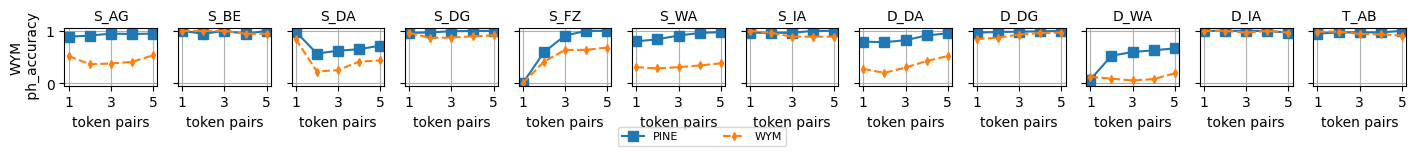

In [17]:
display_faithful_graph(match_score_func=lambda x: x >= 0.0, show_table=False)

loading data for wym


100%|██████████| 12/12 [00:01<00:00,  9.68it/s]


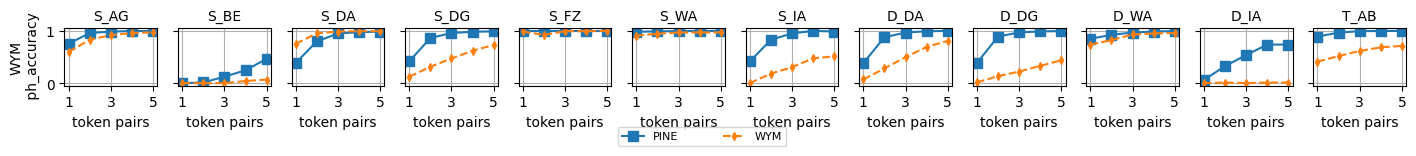

In [18]:
display_faithful_graph(match_score_func=lambda x: x < 0.0, show_table=False)

## Contribution

In [19]:
from typing import Callable
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
import pandas as pd


# def get_data_ids(
#     dataset,
#     lime_results,
#     match_score_func: Callable = None,
#     grand_truth: bool = None,
#     dump: bool = False,
# ):
#     data_ids_in_score_and_gt = []
#     for data_id in lime_results.keys():
#         if dump:
#             print(lime_results[data_id][(None, None)].match_score)
#         if (match_score_func is not None) and not match_score_func(
#             lime_results[data_id][(None, None)].match_score
#         ):
#             continue
#         if (grand_truth is not None) and dataset.test.labels.loc[
#             data_id
#         ] != grand_truth:
#             continue
#         data_ids_in_score_and_gt.append(data_id)
#     return data_ids_in_score_and_gt


def _calc_posthoc_f1(
    rank, match_scores_pertub: Dict[int, np.array], correct: pd.Series, match_side: bool
):
    match_scores_pertub_arr = np.empty((len(match_scores_pertub),), dtype=np.float)
    y = correct.loc[match_scores_pertub.keys()].to_numpy()
    for i, pid in enumerate(match_scores_pertub):
        match_scores_pertub_ = match_scores_pertub[pid]
        # 削除できるものがない場合、この前のスコアを採用
        if match_scores_pertub_.size < rank + 1:
            match_scores_pertub_ = np.pad(
                match_scores_pertub[pid],
                (0, rank + 1 - match_scores_pertub_.size),
                "edge",
            )
        # print(match_scores_pertub[pid])
        # print(match_scores_pertub_)
        match_scores_pertub_arr[i] = match_scores_pertub_[rank]
    # valid_indices = ~np.isnan(match_scores_pertub_arr)
    # y = y[valid_indices].astype(int)
    # y_pred = (match_scores_pertub_arr[valid_indices] > 0).astype(int)
    assert np.sum(np.isnan(match_scores_pertub_arr)) == 0
    y = y.astype(int)
    y_pred = (match_scores_pertub_arr > 0).astype(int)
    if not match_side:  # unmatch side
        y = np.where(y == 0, 1, 0)
        y_pred = np.where(y_pred == 0, 1, 0)
    tp = np.sum((y == 1) & (y_pred == 1))
    fp = np.sum((y == 0) & (y_pred == 1))
    fn = np.sum((y == 1) & (y_pred == 0))
    # print("len=", len(y), "tp=", tp, "fp=", fp, "fn=", fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return f1


def make_contribution_graph_data(match_score_func, grand_truth, match_side):
    matcher_to_dataset_to_methods_to_posthoc_f1 = {}
    for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
        matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name] = {}
        print("loading data for", target_matcher_name)
        print("making side: match") if match_side else print("making side: unmatch")
        for target_dataset_name in tqdm(
            [dataset_names[j] for j in target_dataset_idxs]
        ):
            matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                target_dataset_name
            ] = {}
            dataset = load_dataset(target_dataset_name, dataset_root_dir)
            lime_results = load_lime_result(
                target_dataset_name,
                target_matcher_name,
                pathlib.Path(lime_result_root_dir),
            )
            # 条件に合うdata_idを取得
            data_ids = get_data_ids(
                dataset, lime_results, match_score_func, grand_truth, dump=False
            )
            for target_method_name in [methods[k] for k in target_method_idxs]:
                matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = []
                # 結果スコアをロード
                match_score_delete = load_match_score_delete(
                    target_method_name,
                    target_dataset_name,
                    target_matcher_name,
                    pathlib.Path(eval_data_root_dir),
                )
                # 条件に合うdata_idのみで計算
                match_score_delete = {
                    data_id: match_score_delete[data_id] for data_id in data_ids
                }
                # posthoc accuracyを計算
                for i in range(TOP_N + 1):
                    f1 = _calc_posthoc_f1(
                        i, match_score_delete, dataset.test.labels, match_side
                    )
                    matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                        target_dataset_name
                    ][target_method_name].append(f1)
    return matcher_to_dataset_to_methods_to_posthoc_f1


def display_contribution_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
    match_side: bool = True,
):
    # グラフ描画用データ取得
    matcher_to_dataset_to_methods_to_posthoc_f1 = make_contribution_graph_data(
        match_score_func, grand_truth, match_side
    )

    display_graph(matcher_to_dataset_to_methods_to_posthoc_f1, "f1", x_axis_start=0)

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name],
                TOP_N,
                "F1",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return
    # # グラフ描画
    # fig, axs = plt.subplots(
    #     len(target_matcher_idxs),
    #     len(target_dataset_idxs),
    #     squeeze=False,
    #     figsize=(1.5 * len(target_dataset_idxs), 1.5 * len(target_matcher_idxs)),
    # )
    # y_min = 0.0
    # y_max = 1.0
    # default_markersize = mpl.rcParams["lines.markersize"] - 2
    # for i, target_matcher_idx in enumerate(target_matcher_idxs):
    #     target_matcher_name = matcher_names[target_matcher_idx]
    #     for j, target_dataset_idx in enumerate(target_dataset_idxs):
    #         target_dataset_name = dataset_names[target_dataset_idx]
    #         ax = axs[i, j]
    #         lines = {}
    #         for marker, color, linestyle, target_method_name in zip(
    #             markers,
    #             color_palette,
    #             line_styles,
    #             [methods[k] for k in target_method_idxs],
    #         ):
    #             average = matcher_to_dataset_to_methods_to_posthoc_f1[
    #                 target_matcher_name
    #             ][target_dataset_name][target_method_name]
    #             markersize = (
    #                 default_markersize if len(lines) != 0 else default_markersize + 3
    #             )
    #             (line,) = ax.plot(
    #                 average,
    #                 label=methods_map[target_method_name],
    #                 marker=marker,
    #                 markersize=markersize,
    #                 color=color,
    #                 linestyle=linestyle,
    #             )
    #             lines[methods_map[target_method_name]] = line
    #         # X,Y軸のメモリは、下と左のみ表示
    #         ax.set_xticks([0, 3, 5])
    #         if not ax.get_subplotspec().is_last_row():
    #             ax.tick_params(labelbottom=False)
    #         if not ax.get_subplotspec().is_first_col():
    #             ax.tick_params(labelleft=False)
    #         # タイトル、ラベル
    #         if ax.get_subplotspec().is_first_row():
    #             xlabel_fontsize = ax.xaxis.label.get_fontsize()
    #             ax.set_title(
    #                 datasetname_maps[target_dataset_name], fontsize=xlabel_fontsize
    #             )
    #         if ax.get_subplotspec().is_last_row():
    #             ax.set_xlabel("token pairs")
    #         if ax.get_subplotspec().is_first_col():
    #             ax.set_ylabel(f"{matcher_names_maps[target_matcher_name]}\n f1")
    #         ax.grid(True)
    # # Y軸の範囲を揃える
    # for i, target_matcher_idx in enumerate(target_matcher_idxs):
    #     for j, target_dataset_idx in enumerate(target_dataset_idxs):
    #         ax = axs[i, j]
    #         ax.set_ylim(y_min - 0.05, y_max + 0.05)
    # fig.legend(
    #     lines.values(),
    #     lines.keys(),
    #     fontsize="8",
    #     loc="lower center",
    #     bbox_to_anchor=(0.5, -0.05),
    #     ncol=len(lines.keys()),
    #     columnspacing=4.0,
    # )
    # plt.tight_layout()  # グラフ同士の間隔を調整
    # # plt.subplots_adjust(bottom=0.14)
    # plt.show()

    # # テーブル出力
    # if show_table:
    #     for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
    #         for target_dataset_name in [dataset_names[j] for j in target_dataset_idxs]:
    #             print(target_matcher_name, target_dataset_name)
    #             display(
    #                 pd.DataFrame(
    #                     matcher_to_dataset_to_methods_to_posthoc_f1[
    #                         target_matcher_name
    #                     ][target_dataset_name]
    #                 )
    #             )
    # return

loading data for wym
making side: match


100%|██████████| 12/12 [00:01<00:00, 10.03it/s]


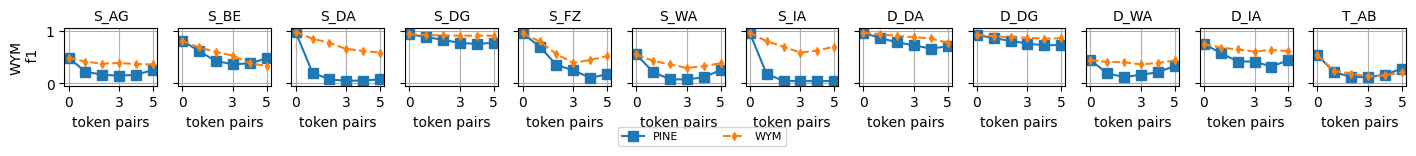

wym


method             PINE             WYM        
metric               F1 ranking      F1 ranking
Matcher dataset                                
WYM     S_AG     0.1606  2.0000  0.3671  1.0000
        S_BE     0.3768  2.0000  0.3784  1.0000
        S_DA     0.0493  2.0000  0.6156  1.0000
        S_DG     0.7502  2.0000  0.9099  1.0000
        S_FZ     0.1026  2.0000  0.4444  1.0000
        S_WA     0.1128  2.0000  0.3234  1.0000
        S_IA     0.0385  2.0000  0.6230  1.0000
        D_DA     0.6606  2.0000  0.8578  1.0000
        D_DG     0.7233  2.0000  0.8508  1.0000
        D_WA     0.2099  2.0000  0.3875  1.0000
        D_IA     0.3158  2.0000  0.6364  1.0000
        T_AB     0.1618  1.0000  0.1502  2.0000
Mean             0.3052  1.9167  0.5454  1.0833

In [20]:
display_contribution_graph(match_side=True, show_table=True)

loading data for wym
making side: unmatch


100%|██████████| 12/12 [00:01<00:00, 10.39it/s]


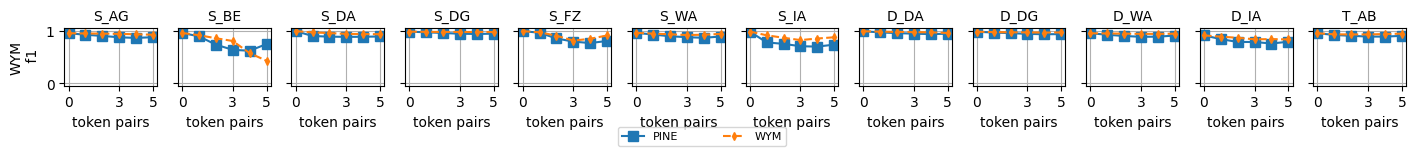

wym


method             PINE             WYM        
metric               F1 ranking      F1 ranking
Matcher dataset                                
WYM     S_AG     0.8651  2.0000  0.9354  1.0000
        S_BE     0.6195  1.0000  0.5741  2.0000
        S_DA     0.8866  2.0000  0.9388  1.0000
        S_DG     0.9402  2.0000  0.9788  1.0000
        S_FZ     0.7667  2.0000  0.8485  1.0000
        S_WA     0.8676  2.0000  0.9264  1.0000
        S_IA     0.6988  2.0000  0.8535  1.0000
        D_DA     0.9375  2.0000  0.9722  1.0000
        D_DG     0.9352  2.0000  0.9674  1.0000
        D_WA     0.8890  2.0000  0.9426  1.0000
        D_IA     0.7578  2.0000  0.8421  1.0000
        T_AB     0.8899  2.0000  0.9399  1.0000
Mean             0.8378  1.9167  0.8933  1.0833

In [21]:
display_contribution_graph(match_side=False, show_table=True)

## Token Pair Semantic Relevance 

- 用いる類似度
  - CosSim
  - Wu and Palmer
- 標準化+Sigmoid
  - あり
  - なし
- null token
  - 平均
  - 非類似度

In [24]:
from typing import Callable
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
import pandas as pd


def _get_average(
    scores: List[np.ndarray],
    axis: int = 0,
    max_length: int = None,
    mode: str = "edge",
    constant_values: float = np.nan,
    dump: bool = False,
) -> np.ndarray:
    if max_length is None:
        max_length = max([len(s) for s in scores])
    if mode == "constant":
        scores = [
            np.pad(
                s[:max_length].astype(float),
                (0, max_length - s[:max_length].shape[0]),
                mode="constant",
                constant_values=constant_values,
            )
            if len(s) != 0
            else np.array([np.nan] * max_length)
            for s in scores
        ]
    else:
        scores = [
            np.pad(
                s[:max_length].astype(float),
                (0, max_length - s[:max_length].shape[0]),
                mode=mode,
            )
            if len(s) != 0
            else np.array([np.nan] * max_length)
            for s in scores
        ]
    if dump:
        print(scores)
    if len(scores) == 0:
        return np.zeros((max_length,))
    scores = np.vstack(scores)
    return np.nanmean(scores, axis=axis)


In [25]:
import numpy as np
from scipy.special import expit  # sigmoid


def calc_stat(token_sim):
    all_sims = np.concatenate(
        [list(idx_to_score.values()) for idx_to_score in token_sim.values()]
    ).astype(float)

    mu = np.nanmean(all_sims)
    sigma = np.nanstd(all_sims)
    return mu, sigma


def standardization(sim, mu, sigma):
    z = (sim - mu) / sigma
    return expit(z)


def calc_dis_sim_score(sims, is_standardization: bool, mu: float, sigma: float):
    if is_standardization:
        scores = standardization(np.array(sims), mu, sigma)
    else:
        scores = np.array(sims)
    return 1.0 - np.nanmean(scores)


def calc_token_rel_score(
    segment_idx,
    entity_pair,
    token_sim_in_data,
    is_standardization: bool,
    is_calc_null_token_dissim: bool,
    mu: float,
    sigma: float,
) -> float:
    score = None
    is_null_token = False
    is_not_exist = False

    token_l_idxs, token_r_idxs = entity_pair.convert_segment_idx_to_entity_idx(
        segment_idx
    )

    # null token の場合は計算して返す
    if len(token_l_idxs) == 0 or len(token_r_idxs) == 0:
        is_null_token = True

        # null_token を計算しない場合は、Noneを返す
        if not is_calc_null_token_dissim:
            return None, is_null_token, is_not_exist

        t_sims_in_other_record = []
        if len(token_l_idxs) == 0:
            token_l_idxs = list(range(entity_pair.entity_l.segment_size()))
        elif len(token_r_idxs) == 0:
            token_r_idxs = list(range(entity_pair.entity_r.segment_size()))
        else:
            raise ValueError("token_l_idxs and token_r_idxs are empty.")
        for token_l_idx in token_l_idxs:
            for token_r_idx in token_r_idxs:
                t_sims_in_other_record.append(
                    token_sim_in_data[(token_l_idx, token_r_idx)]
                )
        t_sims_in_other_record = np.array(t_sims_in_other_record).astype(float)
        # もしレコード内の単語が存在しない、または、全て類似度がNoneの場合は、見つからない
        if len(t_sims_in_other_record) == 0 or np.all(np.isnan(t_sims_in_other_record)):
            is_not_exist = True
            return None, is_null_token, is_not_exist
        score = calc_dis_sim_score(
            t_sims_in_other_record,
            is_standardization,
            mu,
            sigma,
        )
        return score, is_null_token, is_not_exist

    sim = token_sim_in_data[(token_l_idxs[0], token_r_idxs[0])]
    if sim is None:
        is_not_exist = True
        return None, is_null_token, is_not_exist
    if is_standardization:
        score = standardization(sim, mu, sigma)
    else:
        score = sim
    return score, is_null_token, is_not_exist


In [26]:
def make_token_rel_score_data(
    dataset_name,
    matcher_name,
    method_name,
    root_dir,
    sim_kind: str = "cos",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    """token pairの類似度を取得する
    Args:
        dataset_name (str): データセット名
        matcher_name (str): マッチャー名
        method_name (str): 手法名
        root_dir (str): データセットのルートディレクトリ
        sim_kind (str): 類似度の種類
        is_standardization (bool): 標準化するかどうか
        is_calc_null_token_dissim (bool): null token pairの類似度を計算するかどうか
    Returns:
        dict: token pair relative score
        dict: token pair type to number
    """
    # データセット内の全token pairの類似度を取得する
    if sim_kind == "cos":
        token_sim = load_token_sim_score(
            dataset_name,
            pathlib.Path(token_sim_result_root_dir),
        )
    elif sim_kind == "wup":
        token_sim = load_token_sim_score(
            dataset_name,
            pathlib.Path(token_sim_wup_result_root_dir),
        )
    else:
        raise ValueError("Invalid sim_kind: {}".format(sim_kind))

    # explanationsを取得する
    if method_name == "wym":
        pair_explanations = load_wym_pair_explanation(
            dataset_name, pathlib.Path(wym_result_root_dir)
        )
    else:
        pair_explanations = load_pair_explanations(
            method_name,
            dataset_name,
            matcher_name,
            pathlib.Path(root_dir),
        )

    # 全体の平均と標準偏差を計算
    mu, sigma = calc_stat(token_sim)
    # print(
    #     dataset_name,
    #     matcher_name,
    #     method_name,
    #     "mu=",
    #     mu,
    #     "sigma=",
    #     sigma,
    # )
    # 説明内のtoken pairの類似度を取得する
    token_rel_score_data = {}
    # 以下の統計データを出力する
    token_pair_type_to_num = {
        "null_token_and_not_exist": 0,
        "not_null_token_and_not_exist": 0,
        "null_token_and_exist": 0,
        "not_null_token_and_exist": 0,
    }
    for data_id in pair_explanations.keys():
        pair_exp, entity_pair = pair_explanations[data_id]
        scores = []
        for attr in pair_exp.attributions:
            # スコア計算
            token_l_idx, token_r_idx = entity_pair.convert_segment_idx_to_entity_idx(
                attr.index
            )
            score, is_null_token, is_not_exist = calc_token_rel_score(
                attr.index,
                entity_pair,
                token_sim[data_id],
                is_standardization,
                is_calc_null_token_dissim,
                mu,
                sigma,
            )
            scores.append(score)
        token_rel_score_data[data_id] = np.array(scores)
        if is_null_token and is_not_exist:
            token_pair_type_to_num["null_token_and_not_exist"] += 1
        elif is_null_token and not is_not_exist:
            token_pair_type_to_num["null_token_and_exist"] += 1
        elif not is_null_token and is_not_exist:
            token_pair_type_to_num["not_null_token_and_not_exist"] += 1
        elif not is_null_token and not is_not_exist:
            token_pair_type_to_num["not_null_token_and_exist"] += 1

    return token_rel_score_data, token_pair_type_to_num

In [27]:
from collections import defaultdict


def nan_stats(array_list):
    # 全要素を一つの1次元配列に結合
    all_values = np.concatenate(array_list)

    # NaNを無視して統計量を計算
    min_val = np.nanmin(all_values)
    max_val = np.nanmax(all_values)
    avg_val = np.nanmean(all_values)

    return min_val, max_val, avg_val


@lru_cache(maxsize=None)
def make_token_rel_score_average_data(
    match_score_func,
    grand_truth,
    topk=5,
    fill_na="avg",
    sim_kind: str = "cos",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    """token pair relevance score の平均を計算"""
    matcher_to_dataset_to_methods_to_token_rel = {}
    matcher_to_dataset_to_methods_to_token_rel_stat = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
        matcher_to_dataset_to_methods_to_token_rel[target_matcher_name] = {}
        print("loading data for", target_matcher_name)
        for target_dataset_name in tqdm(
            [dataset_names[j] for j in target_dataset_idxs]
        ):
            matcher_to_dataset_to_methods_to_token_rel[target_matcher_name][
                target_dataset_name
            ] = {}
            dataset = load_dataset(target_dataset_name, dataset_root_dir)
            lime_results = load_lime_result(
                target_dataset_name,
                target_matcher_name,
                pathlib.Path(lime_result_root_dir),
            )
            # 条件に合うdata_idを取得
            data_ids = get_data_ids(
                dataset, lime_results, match_score_func, grand_truth, dump=False
            )
            for target_method_name in [methods[k] for k in target_method_idxs]:
                matcher_to_dataset_to_methods_to_token_rel[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = {}
                # rel score データ作成
                rel_scores, rel_scores_stat = make_token_rel_score_data(
                    target_dataset_name,
                    target_matcher_name,
                    target_method_name,
                    eval_data_root_dir,
                    sim_kind=sim_kind,
                    is_standardization=is_standardization,
                    is_calc_null_token_dissim=is_calc_null_token_dissim,
                )
                # 上位kまでの全体の平均を取る。
                # TODO: この部分は、もう少し綺麗に書けるはず。
                rel_score_avgs = []
                for target_rank in range(1, topk + 1):
                    # nanを埋める値を計算
                    (
                        rel_score_min_wholl_data,
                        rel_score_max_wholl_data,
                        rel_score_avg_wholl_data,
                    ) = nan_stats(
                        [
                            scores[:target_rank].astype(float)
                            for scores in rel_scores.values()
                        ],
                    )
                    if fill_na == "min":
                        rel_score_fill_na = rel_score_min_wholl_data
                    elif fill_na == "max":
                        rel_score_fill_na = rel_score_max_wholl_data
                    elif fill_na == "avg":
                        rel_score_fill_na = rel_score_avg_wholl_data
                    else:
                        raise ValueError(f"Invalid fill_na value: {fill_na}")

                    # 条件に合うdata_idのみで平均を計算。Noneの部分には、fill_naを入れる。
                    rel_score_avg_target = _get_average(
                        [
                            np.nan_to_num(
                                rel_scores[data_id][:target_rank].astype(float),
                                nan=rel_score_fill_na,
                            )
                            for data_id in data_ids
                        ],
                        axis=None,
                        mode="constant",
                        constant_values=np.nan,
                    )
                    rel_score_avgs.append(rel_score_avg_target)

                matcher_to_dataset_to_methods_to_token_rel[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = rel_score_avgs
                matcher_to_dataset_to_methods_to_token_rel_stat[
                    target_matcher_name
                ][target_dataset_name][target_method_name] = rel_scores_stat
    return matcher_to_dataset_to_methods_to_token_rel, matcher_to_dataset_to_methods_to_token_rel_stat


In [28]:
def display_token_rel_score_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = False,
    fill_na: str = "avg",
    sim_kind: str = "cos",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    # グラフ描画用データ取得(tokensim)
    matcher_to_dataset_to_methods_to_token_rel, matcher_to_dataset_to_methods_to_token_rel_stat = make_token_rel_score_average_data(
        match_score_func,
        grand_truth,
        fill_na=fill_na,
        sim_kind=sim_kind,
        is_standardization=is_standardization,
        is_calc_null_token_dissim=is_calc_null_token_dissim,
    )
    # グラフ描画
    display_graph(
        matcher_to_dataset_to_methods_to_token_rel, "rel score", x_axis_start=1
    )
    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_token_rel[
                    target_matcher_name
                ],
                TOP_N,
                "Token Rel",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)

    return

### CosSim, 標準化なし, null token=平均

loading data for wym


100%|██████████| 12/12 [01:01<00:00,  5.16s/it]


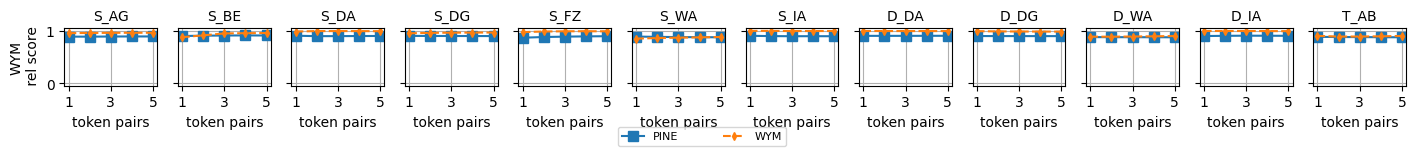

wym


method             PINE               WYM          
metric          ranking Token Rel ranking Token Rel
Matcher dataset                                    
WYM     S_AG        2.0    0.8931     1.0    0.9633
        S_BE        2.0    0.9114     1.0    0.9590
        S_DA        2.0    0.9023     1.0    0.9936
        S_DG        2.0    0.9002     1.0    0.9685
        S_FZ        2.0    0.8977     1.0    0.9914
        S_WA        2.0    0.8772     1.0    0.8832
        S_IA        2.0    0.8973     1.0    0.9968
        D_DA        2.0    0.9059     1.0    0.9955
        D_DG        2.0    0.8994     1.0    0.9855
        D_WA        2.0    0.8774     1.0    0.9012
        D_IA        2.0    0.9054     1.0    0.9944
        T_AB        2.0    0.8777     1.0    0.9026
Mean                2.0    0.8954     1.0    0.9612

In [29]:
display_token_rel_score_graph(
    show_table = True,
    fill_na="avg",
    sim_kind="cos",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

### 類似度とfaithfulを組み合わせた指標

- faithful の unmatch については、全く関係ない単語の組合せのほうが上がりやすい仕組みになっている
- 塁維持度合とfaithfulを組み合わせた指標を考えてみる
  
$
post-hoc-accuracy(k) = 1 / M \sum_{m=1}^{M}  [[ y^{(m)} = y_{k}^{(m)} ]]
$

$
token-pair-simirarity(k) = 1 / M \sum_{m=1}^{M} 1 / k \sum_{k=1}^{k} WupSim(<t_1, t_2>_k^{(m)})
$

$
post-hoc-accuracy-with-token-sim(k) = post-hoc-accuracy(k) * token-pair-simirarity(k)
$

In [39]:
def display_faithful_with_token_sim_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
    fill_na: str = "avg",
    sim_kind: str = "wup",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    # グラフ描画用データ取得(faitful)
    matcher_to_dataset_to_methods_to_posthoc_acc = make_faithful_graph_data(
        match_score_func, grand_truth
    )
    # グラフ描画用データ取得(tokenrel)
    matcher_to_dataset_to_methods_to_token_sim, _ = make_token_rel_score_average_data(
        match_score_func, grand_truth,
        fill_na=fill_na,
        sim_kind=sim_kind,
        is_standardization=is_standardization,
        is_calc_null_token_dissim=is_calc_null_token_dissim,
    )
    # 積算
    matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim = {}
    for target_matcher_name in [
        matcher_names[target_matcher_idx] for target_matcher_idx in target_matcher_idxs
    ]:
        matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
            target_matcher_name
        ] = {}
        for target_dataset_name in [
            dataset_names[target_dataset_idx]
            for target_dataset_idx in target_dataset_idxs
        ]:
            matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
                target_matcher_name
            ][target_dataset_name] = {}
            for target_method_name in [methods[k] for k in target_method_idxs]:
                post_hoc_accs = np.array(
                    matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                        target_dataset_name
                    ][target_method_name]["accuracy"][1 : TOP_N + 1]
                )
                token_sim = np.array(
                    matcher_to_dataset_to_methods_to_token_sim[target_matcher_name][
                        target_dataset_name
                    ][target_method_name][:TOP_N]
                )
                matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
                    target_matcher_name
                ][target_dataset_name][target_method_name] = post_hoc_accs * token_sim

    # グラフ描画
    display_graph(
        matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim, "acc with rel"
    )
    display_graph(matcher_to_dataset_to_methods_to_token_sim, "token rel")

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
                    target_matcher_name
                ],
                TOP_N,
                "post_hoc_acc",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return

### 類似度とContributeを組み合わせた指標

- Contribute の match については、全く関係ない単語の組合せのほうが下がりやすい
- 類似度とContributeを組み合わせた指標を考えてみる
  
$
F1(label, k) = 2 * Precision(label, k) * Recall(label, k) / (Precision(label, k) + Recall(label, k))
$

$
Precition(label,k) = {\sum_{m=1}^{M} [[ y_{del_k}^{(m)} = label ]] [[ y_{true}^{(m)} = label ]] } / {\sum_{m=1}^{M} [[ y_{del_k}^{(m)} = label ]] }
$

$
Recall(label,k) = {\sum_{m=1}^{M} [[ y_{del_k}^{(m)} = label ]] [[ y_{true}^{(m)} = label ]] } / {\sum_{m=1}^{M} [[ y_{true}^{(m)} = label ]] }
$

$
token-pair-simirarity(k) = 1 / M \sum_{m=1}^{M} 1 / k \sum_{k=1}^{k} WupSim(<t_1, t_2>_k^{(m)})
$

$
F1-with-token-sim(k) = ( 1 - F1(k) ) * token-pair-simirarity(k)
$

In [41]:
def display_contribution_with_token_sim_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
    match_side: bool = True,
    fill_na: str = "avg",
    sim_kind: str = "wup",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    # グラフ描画用データ取得(contribution)
    matcher_to_dataset_to_methods_to_posthoc_f1 = make_contribution_graph_data(
        match_score_func, grand_truth, match_side
    )
    # グラフ描画用データ取得(tokensim)
    matcher_to_dataset_to_methods_to_token_sim, _ = make_token_rel_score_average_data(
        match_score_func, grand_truth,
        fill_na=fill_na,
        sim_kind=sim_kind,
        is_standardization=is_standardization,
        is_calc_null_token_dissim=is_calc_null_token_dissim,
    )
    # 積算
    matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim = {}
    for target_matcher_name in [
        matcher_names[target_matcher_idx] for target_matcher_idx in target_matcher_idxs
    ]:
        matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
            target_matcher_name
        ] = {}
        for target_dataset_name in [
            dataset_names[target_dataset_idx]
            for target_dataset_idx in target_dataset_idxs
        ]:
            matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
                target_matcher_name
            ][target_dataset_name] = {}
            for target_method_name in [methods[k] for k in target_method_idxs]:
                post_hoc_f1s = np.array(
                    matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                        target_dataset_name
                    ][target_method_name][1 : TOP_N + 1]
                )
                token_sim = np.array(
                    matcher_to_dataset_to_methods_to_token_sim[target_matcher_name][
                        target_dataset_name
                    ][target_method_name][:TOP_N]
                )
                matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
                    target_matcher_name
                ][target_dataset_name][target_method_name] = (
                    1 - post_hoc_f1s
                ) * token_sim

    # グラフ描画
    display_graph(
        matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim, "f1 with sim"
    )

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
                    target_matcher_name
                ],
                TOP_N,
                "F1",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return

loading data for wym


100%|██████████| 12/12 [00:01<00:00,  9.10it/s]


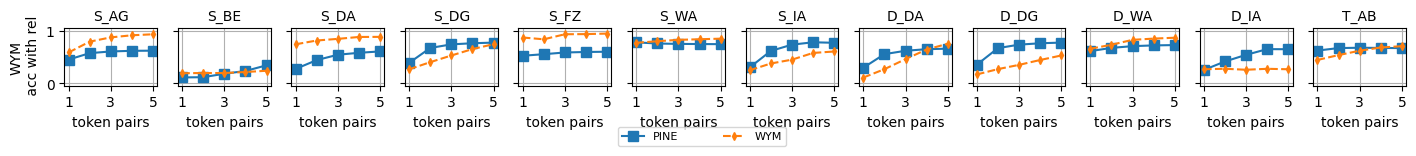

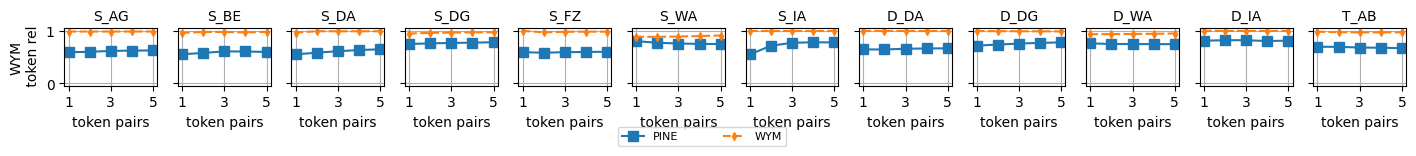

wym


method             PINE                  WYM             
metric          ranking post_hoc_acc ranking post_hoc_acc
Matcher dataset                                          
WYM     S_AG     2.0000       0.6212  1.0000       0.9347
        S_BE     1.0000       0.3411  2.0000       0.2371
        S_DA     2.0000       0.6070  1.0000       0.8853
        S_DG     1.0000       0.7757  2.0000       0.7454
        S_FZ     2.0000       0.6010  1.0000       0.9480
        S_WA     2.0000       0.7456  1.0000       0.8509
        S_IA     1.0000       0.7719  2.0000       0.6055
        D_DA     2.0000       0.6596  1.0000       0.7537
        D_DG     1.0000       0.7757  2.0000       0.5292
        D_WA     2.0000       0.7282  1.0000       0.8689
        D_IA     1.0000       0.6487  2.0000       0.2657
        T_AB     2.0000       0.6702  1.0000       0.7070
Mean             1.5833       0.6622  1.4167       0.6943

In [50]:
display_faithful_with_token_sim_graph(
    show_table=True,
    fill_na="avg",
    sim_kind="wup",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

loading data for wym
making side: match


100%|██████████| 12/12 [00:01<00:00,  9.59it/s]


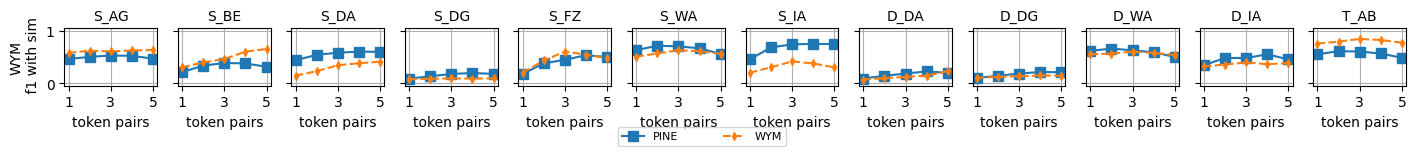

wym


method             PINE             WYM        
metric               F1 ranking      F1 ranking
Matcher dataset                                
WYM     S_AG     0.4682     2.0  0.6347     1.0
        S_BE     0.3137     2.0  0.6539     1.0
        S_DA     0.5996     1.0  0.4113     2.0
        S_DG     0.1777     1.0  0.0918     2.0
        S_FZ     0.4994     1.0  0.4753     2.0
        S_WA     0.5602     2.0  0.5629     1.0
        S_IA     0.7459     1.0  0.3016     2.0
        D_DA     0.1961     2.0  0.2316     1.0
        D_DG     0.2099     1.0  0.1404     2.0
        D_WA     0.5015     2.0  0.5381     1.0
        D_IA     0.4546     1.0  0.3841     2.0
        T_AB     0.4837     2.0  0.7743     1.0
Mean             0.4342     1.5  0.4333     1.5

In [51]:
display_contribution_with_token_sim_graph(
    match_side=True,
    show_table=True,
    fill_na="avg",
    sim_kind="wup",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

loading data for wym
making side: unmatch


100%|██████████| 12/12 [00:01<00:00, 10.01it/s]


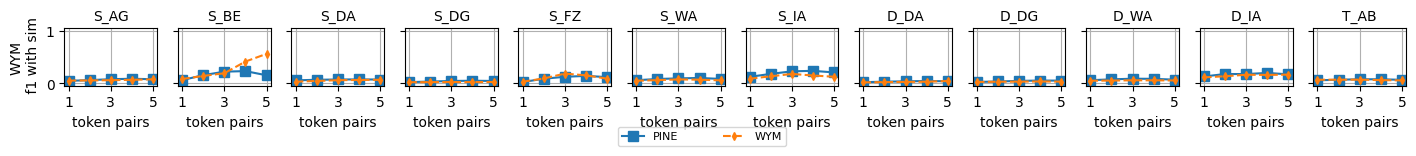

wym


method             PINE             WYM        
metric               F1 ranking      F1 ranking
Matcher dataset                                
WYM     S_AG     0.0754  1.0000  0.0735  2.0000
        S_BE     0.1505  2.0000  0.5605  1.0000
        S_DA     0.0692  1.0000  0.0640  2.0000
        S_DG     0.0420  1.0000  0.0223  2.0000
        S_FZ     0.1155  1.0000  0.0861  2.0000
        S_WA     0.0811  1.0000  0.0536  2.0000
        S_IA     0.2050  1.0000  0.1226  2.0000
        D_DA     0.0362  2.0000  0.0411  1.0000
        D_DG     0.0485  1.0000  0.0296  2.0000
        D_WA     0.0668  1.0000  0.0518  2.0000
        D_IA     0.1687  1.0000  0.1632  2.0000
        T_AB     0.0636  1.0000  0.0527  2.0000
Mean             0.0935  1.1667  0.1101  1.8333

In [52]:
display_contribution_with_token_sim_graph(
    match_side=False,
    show_table=True,
    fill_na="avg",
    sim_kind="wup",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)